In [2]:
from imports import *

In [3]:
result_list = glob.glob("stats/pi*")

print("Number of tested combinations: {}".format(len(result_list)))

Number of tested combinations: 4


In [4]:
result_list

['stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-mix--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-swp--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-inv--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-ins--stp-1.500000--pop-8.txt']


Instância: E-n22-k4.evrp
1º melhor | Fitness: 385.440000 | Mutação: mix | Execução: 3
2º melhor | Fitness: 385.440000 | Mutação: mix | Execução: 4
3º melhor | Fitness: 385.440000 | Mutação: mix | Execução: 6


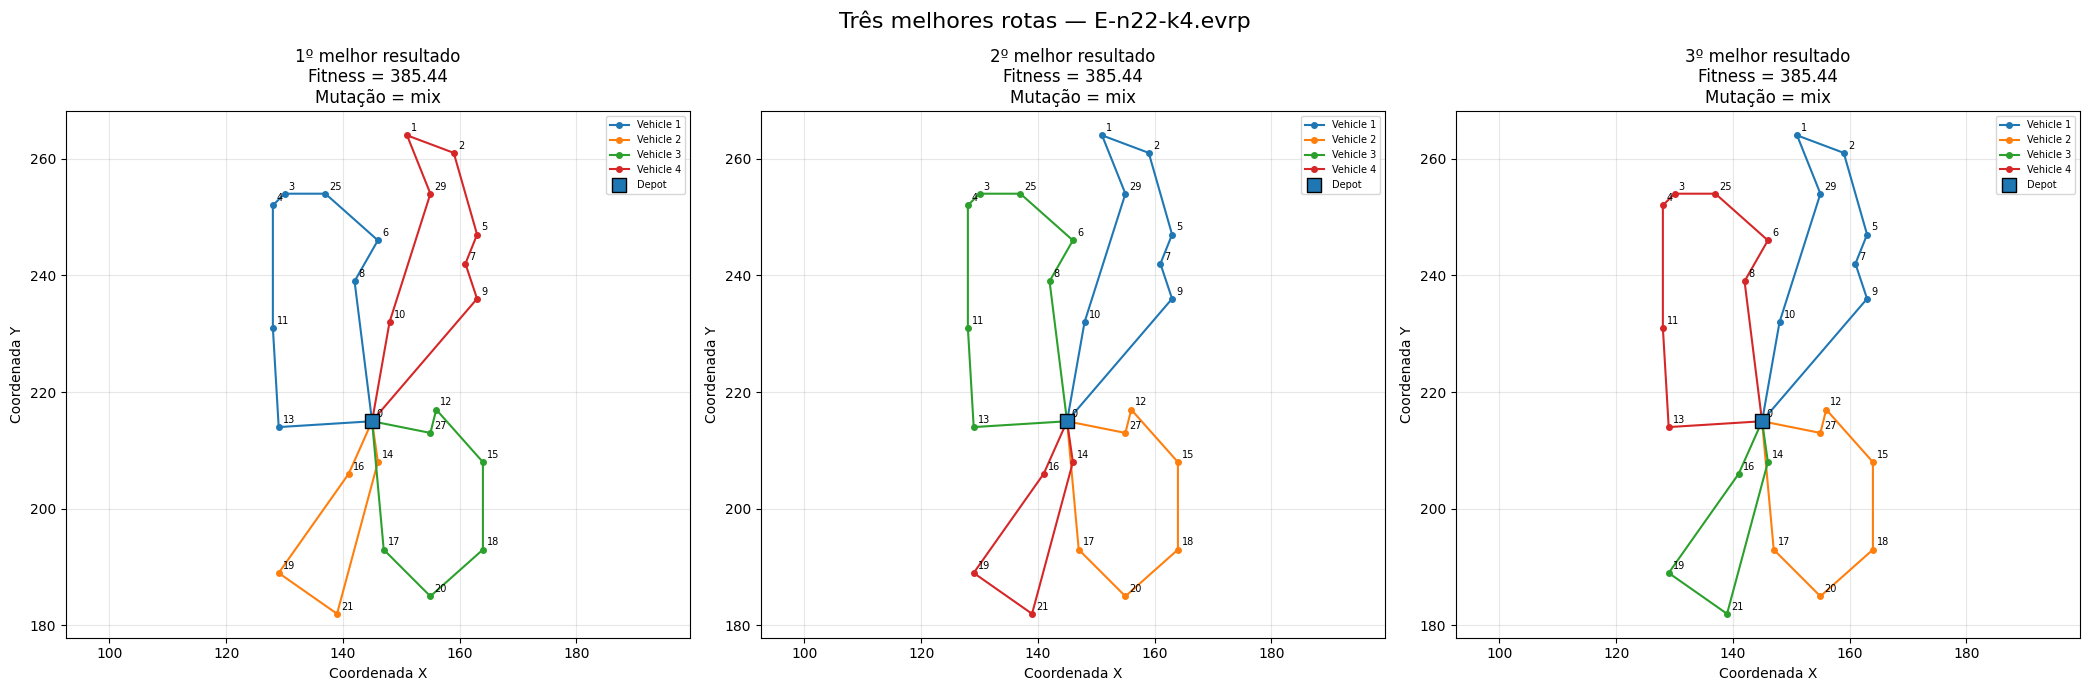

Figura salva em: route_plots\top_3_routes_E-n22-k4.png


In [5]:
def get_instance_name_from_result(result_file):
    # Get only the file name
    file_name = os.path.basename(result_file)

    # Extract the instance name between "pi-" and "--mtr-"
    instance_name = file_name.split("pi-")[-1].split("--mtr-")[0]

    return instance_name


def get_mutation_method_from_result(result_file):
    # Get only the file name
    file_name = os.path.basename(result_file)

    # Extract the mutation method between "--mtm-" and "--"
    mutation_method = file_name.split("--mtm-")[-1].split("--")[0]

    return mutation_method


def read_routes_and_fitness(result_file):
    # Store the routes found in the result file
    routes = []

    # Store the fitness values found in the result file
    fitness_values = []

    # Open the result file
    with open(result_file, "r", encoding="utf-8") as result_data:

        # Read the file line by line
        for raw_line in result_data:

            # Remove spaces and line breaks
            line = raw_line.strip()

            # Ignore empty lines
            if line == "":
                continue

            # Read route lines
            if line.startswith("route:"):

                # Remove the word "route:"
                route_text = line.split(
                    "route:",
                    1
                )[1]

                # Remove everything after ";"
                # Example: ";viable: 1"
                route_text = route_text.split(
                    ";",
                    1
                )[0]

                # Convert the route nodes from text to integers
                route = [
                    int(value.strip())
                    for value in route_text.split(",")
                    if value.strip() != ""
                ]

                # Add the route to the route list
                routes.append(route)

            else:

                # Try to interpret the line as a fitness value
                try:

                    fitness_value = float(line)

                    # Add the fitness value to the list
                    fitness_values.append(
                        fitness_value
                    )

                # Ignore lines containing Mean,
                # Std Dev, Min, Max, etc.
                except ValueError:
                    pass

    return routes, fitness_values


def find_instance_file(instance_name):
    # Search recursively for the EVRP instance
    instance_files = glob.glob(
        os.path.join("**", instance_name),
        recursive=True
    )

    # Return the first file found
    if len(instance_files) > 0:
        return instance_files[0]

    # Return None if the file was not found
    return None


def read_instance_coordinates(instance_file):
    # Store node coordinates
    coordinates = {}

    # Indicate whether the coordinate section is being read
    reading_coordinates = False

    # Open the EVRP instance file
    with open(instance_file, "r", encoding="utf-8") as instance_data:

        # Read the file line by line
        for raw_line in instance_data:

            # Remove spaces and line breaks
            line = raw_line.strip()

            # Ignore empty lines
            if line == "":
                continue

            # Start reading coordinates
            if line.upper() == "NODE_COORD_SECTION":
                reading_coordinates = True
                continue

            # Process the coordinate section
            if reading_coordinates:

                # Stop when another section begins
                if (
                    line.upper().endswith("_SECTION")
                    or line.upper() == "EOF"
                ):
                    break

                # Divide the line into columns
                parts = line.split()

                # A coordinate line must contain node, x and y
                if len(parts) >= 3:

                    try:
                        # Read the node identifier
                        node = int(float(parts[0]))

                        # Read the X coordinate
                        x_coordinate = float(parts[1])

                        # Read the Y coordinate
                        y_coordinate = float(parts[2])

                        # Store the node coordinates
                        coordinates[node] = (
                            x_coordinate,
                            y_coordinate
                        )

                    except ValueError:
                        pass

    return coordinates


def get_coordinate_offset(route, coordinates):
    # Count route nodes that directly exist in the coordinates
    direct_matches = sum(
        node in coordinates
        for node in route
    )

    # Count route nodes that exist after adding one
    shifted_matches = sum(
        node + 1 in coordinates
        for node in route
    )

    # Some EVRP files start node numbering at 1,
    # while the C++ route starts node numbering at 0
    if shifted_matches > direct_matches:
        return 1

    return 0


def split_route_by_vehicle(route):
    # Store each vehicle route
    vehicle_routes = []

    # Start the current route at the depot
    current_route = []

    # Read every node in the complete solution
    for node in route:

        # Add the node to the current vehicle route
        current_route.append(node)

        # Node zero represents the depot
        if node == 0 and len(current_route) > 1:

            # Save the completed vehicle route
            vehicle_routes.append(current_route)

            # Start the next vehicle route at the depot
            current_route = [0]

    # Save the final route if it was not closed
    if len(current_route) > 1:
        vehicle_routes.append(current_route)

    return vehicle_routes


def plot_one_solution(
    axis,
    route,
    coordinates,
    fitness,
    mutation_method,
    rank
):
    # Determine whether node identifiers require an offset
    coordinate_offset = get_coordinate_offset(
        route,
        coordinates
    )

    # Divide the complete solution into vehicle routes
    vehicle_routes = split_route_by_vehicle(route)

    # Plot each vehicle route
    for vehicle_index, vehicle_route in enumerate(vehicle_routes):

        # Store X coordinates
        x_values = []

        # Store Y coordinates
        y_values = []

        # Read each node in the vehicle route
        for node in vehicle_route:

            # Convert the route node to the coordinate identifier
            coordinate_node = node + coordinate_offset

            # Check whether the node has coordinates
            if coordinate_node in coordinates:

                # Get node coordinates
                x_coordinate, y_coordinate = coordinates[
                    coordinate_node
                ]

                # Add X coordinate
                x_values.append(x_coordinate)

                # Add Y coordinate
                y_values.append(y_coordinate)

        # Plot the current vehicle route
        axis.plot(
            x_values,
            y_values,
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=f"Vehicle {vehicle_index + 1}"
        )

    # Plot the node numbers
    for node in set(route):

        # Convert route node to coordinate identifier
        coordinate_node = node + coordinate_offset

        # Check whether the node exists
        if coordinate_node in coordinates:

            # Get node coordinates
            x_coordinate, y_coordinate = coordinates[
                coordinate_node
            ]

            # Add the node number beside the point
            axis.annotate(
                str(node),
                (x_coordinate, y_coordinate),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=7
            )

    # Get the depot coordinate identifier
    depot_node = coordinate_offset

    # Highlight the depot
    if depot_node in coordinates:

        # Get depot coordinates
        depot_x, depot_y = coordinates[depot_node]

        # Plot the depot using a square marker
        axis.scatter(
            depot_x,
            depot_y,
            marker="s",
            s=90,
            edgecolors="black",
            zorder=5,
            label="Depot"
        )

    # Create the plot title
    axis.set_title(
        f"{rank}º melhor resultado\n"
        f"Fitness = {fitness:.2f}\n"
        f"Mutação = {mutation_method}"
    )

    # Add the X-axis label
    axis.set_xlabel("Coordenada X")

    # Add the Y-axis label
    axis.set_ylabel("Coordenada Y")

    # Add a grid
    axis.grid(True, alpha=0.3)

    # Use the same scale on both axes
    axis.axis("equal")

    # Add the legend
    axis.legend(fontsize=7)


# Store every route from every result file
solutions_by_instance = {}


# Read each file in result_list
for result_file in result_list:

    # Extract the instance name
    instance_name = get_instance_name_from_result(
        result_file
    )

    # Extract the mutation method
    mutation_method = get_mutation_method_from_result(
        result_file
    )

    # Read routes and fitness values
    file_routes, file_fitness = read_routes_and_fitness(
        result_file
    )

    # Create the instance entry if it does not exist
    if instance_name not in solutions_by_instance:
        solutions_by_instance[instance_name] = []

    # Use the smallest size to avoid invalid positions
    number_of_solutions = min(
        len(file_routes),
        len(file_fitness)
    )

    # Associate each route with its respective fitness
    for run_index in range(number_of_solutions):

        # Add the solution to the instance
        solutions_by_instance[instance_name].append(
            {
                "route": file_routes[run_index],
                "fitness": file_fitness[run_index],
                "mutation_method": mutation_method,
                "run": run_index + 1,
                "result_file": result_file
            }
        )


# Create a folder to save the route figures
os.makedirs("route_plots", exist_ok=True)


# Process each EVRP instance
for instance_name, instance_solutions in solutions_by_instance.items():

    # Sort solutions by fitness in ascending order
    sorted_solutions = sorted(
        instance_solutions,
        key=lambda solution: solution["fitness"]
    )

    # Select the three best solutions
    top_three_solutions = sorted_solutions[:3]

    # Show the selected solutions
    print(f"\nInstância: {instance_name}")

    # Print information about each selected route
    for rank, solution in enumerate(
        top_three_solutions,
        start=1
    ):

        print(
            f"{rank}º melhor | "
            f"Fitness: {solution['fitness']:.6f} | "
            f"Mutação: {solution['mutation_method']} | "
            f"Execução: {solution['run']}"
        )

    # Search for the EVRP instance file
    instance_file = find_instance_file(instance_name)

    # Check whether the instance file was found
    if instance_file is None:

        print(
            f"Arquivo da instância não encontrado: "
            f"{instance_name}"
        )

        continue

    # Read the node coordinates
    coordinates = read_instance_coordinates(
        instance_file
    )

    # Check whether coordinates were found
    if len(coordinates) == 0:

        print(
            f"Coordenadas não encontradas em: "
            f"{instance_file}"
        )

        continue

    # Create one figure with three graphs
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(21, 7)
    )

    # Plot each of the three best routes
    for plot_index, solution in enumerate(
        top_three_solutions
    ):

        plot_one_solution(
            axis=axes[plot_index],
            route=solution["route"],
            coordinates=coordinates,
            fitness=solution["fitness"],
            mutation_method=solution["mutation_method"],
            rank=plot_index + 1
        )

    # Add a main title
    figure.suptitle(
        f"Três melhores rotas — {instance_name}",
        fontsize=16
    )

    # Adjust spacing
    figure.tight_layout()

    # Remove the EVRP extension from the output name
    output_instance_name = instance_name.replace(
        ".evrp",
        ""
    )

    # Define the output file
    output_file = os.path.join(
        "route_plots",
        f"top_3_routes_{output_instance_name}.png"
    )

    # Save the figure
    figure.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    # Display the figure
    plt.show()

    # Show the output file path
    print(f"Figura salva em: {output_file}")


CONVERGENCE CURVES
Instance: E-n22-k4.evrp
1º best | Fitness: 385.44 | Mutation: mix | Run: 3 | Seed: 3
2º best | Fitness: 385.44 | Mutation: mix | Run: 4 | Seed: 4
3º best | Fitness: 385.44 | Mutation: mix | Run: 6 | Seed: 6


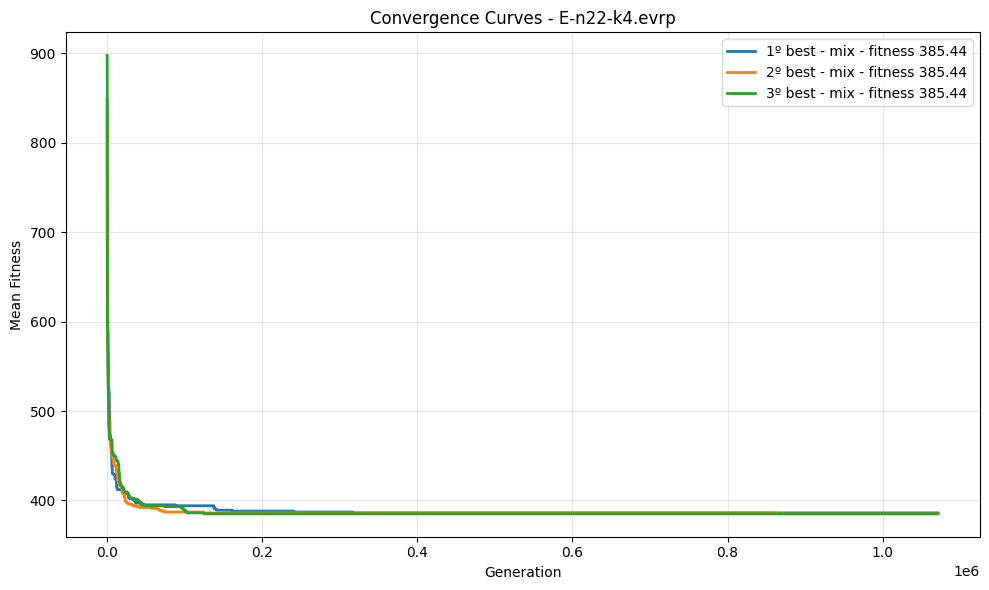

In [6]:
def get_curve_file(result_file):
    # Get the result file name
    file_name = os.path.basename(result_file)

    # Change .txt extension to .csv
    curve_file_name = file_name.replace(
        ".txt",
        ".csv"
    )

    # Build the path to the evolution curve file
    curve_file = os.path.join(
        "evolution_curves",
        curve_file_name
    )

    return curve_file


# ============================================================
# PROCESS EACH INSTANCE
# ============================================================

for instance_name, instance_solutions in solutions_by_instance.items():

    # Sort all solutions from the smallest fitness
    # to the largest fitness
    sorted_solutions = sorted(
        instance_solutions,
        key=lambda solution: solution["fitness"]
    )

    # Select the three best final solutions
    top_three_solutions = sorted_solutions[:3]


    print(
        "\n========================================"
    )

    print(
        "CONVERGENCE CURVES"
    )

    print(
        "Instance:",
        instance_name
    )

    print(
        "========================================"
    )


    # Create one graph for this instance
    plt.figure(
        figsize=(10, 6)
    )


    # ========================================================
    # READ THE CURVE OF EACH OF THE THREE BEST SOLUTIONS
    # ========================================================

    for rank, solution in enumerate(
        top_three_solutions,
        start=1
    ):

        # Final fitness of this solution
        fitness = solution[
            "fitness"
        ]

        # Mutation method
        mutation_method = solution[
            "mutation_method"
        ]

        # Run number
        run = solution[
            "run"
        ]

        # Result file that generated this solution
        result_file = solution[
            "result_file"
        ]


        # ----------------------------------------------------
        # FIND THE CORRESPONDING CURVE FILE
        # ----------------------------------------------------

        curve_file = get_curve_file(
            result_file
        )


        # Check whether the curve file exists
        if not os.path.exists(
            curve_file
        ):

            print(
                f"Curve file not found: "
                f"{curve_file}"
            )

            continue


        # ----------------------------------------------------
        # READ CURVE CSV
        # ----------------------------------------------------

        curve_data = pd.read_csv(
            curve_file
        )


        # Remove spaces from column names
        curve_data.columns = (
            curve_data.columns
            .str.strip()
        )


        # ----------------------------------------------------
        # CHECK REQUIRED COLUMNS
        # ----------------------------------------------------

        required_columns = [
            "seed",
            "generation",
            "fit_mean",
            "fit_std"
        ]


        if not all(
            column in curve_data.columns
            for column in required_columns
        ):

            print(
                f"Invalid columns in: "
                f"{curve_file}"
            )

            continue


        # ----------------------------------------------------
        # FIND THE SEED OF THE SELECTED RUN
        # ----------------------------------------------------

        # Get seeds in the same order they appear in the file
        seeds = pd.unique(
            curve_data["seed"]
        )


        # The run index starts at 1
        # Python index starts at 0
        run_index = run - 1


        # Check whether the run exists
        if run_index >= len(seeds):

            print(
                f"Run {run} not found in "
                f"{curve_file}"
            )

            continue


        # Get the seed corresponding to this run
        selected_seed = seeds[
            run_index
        ]


        # ----------------------------------------------------
        # GET ONLY THE SELECTED RUN
        # ----------------------------------------------------

        selected_curve = curve_data[

            curve_data[
                "seed"
            ] == selected_seed

        ].copy()


        # Sort points by generation
        selected_curve = (
            selected_curve
            .sort_values(
                "generation"
            )
        )


        # ----------------------------------------------------
        # REMOVE POSSIBLE DUPLICATED HEADERS OR INVALID VALUES
        # ----------------------------------------------------

        selected_curve[
            "generation"
        ] = pd.to_numeric(

            selected_curve[
                "generation"
            ],

            errors="coerce"
        )


        selected_curve[
            "fit_mean"
        ] = pd.to_numeric(

            selected_curve[
                "fit_mean"
            ],

            errors="coerce"
        )


        # Remove invalid rows
        selected_curve = (
            selected_curve
            .dropna(
                subset=[
                    "generation",
                    "fit_mean"
                ]
            )
        )


        # ----------------------------------------------------
        # SHOW INFORMATION
        # ----------------------------------------------------

        print(
            f"{rank}º best | "
            f"Fitness: {fitness:.2f} | "
            f"Mutation: {mutation_method} | "
            f"Run: {run} | "
            f"Seed: {selected_seed}"
        )


        # ----------------------------------------------------
        # PLOT CONVERGENCE CURVE
        # ----------------------------------------------------

        plt.plot(

            selected_curve[
                "generation"
            ],

            selected_curve[
                "fit_mean"
            ],

            linewidth=2,

            label=(
                f"{rank}º best - "
                f"{mutation_method} - "
                f"fitness {fitness:.2f}"
            )
        )


    # ========================================================
    # GRAPH CONFIGURATION
    # ========================================================

    plt.title(
        f"Convergence Curves - "
        f"{instance_name}"
    )


    plt.xlabel(
        "Generation"
    )


    plt.ylabel(
        "Mean Fitness"
    )


    plt.grid(
        True,
        alpha=0.3
    )


    plt.legend()


    plt.tight_layout()


    # ========================================================
    # SHOW GRAPH
    # ========================================================

    plt.show()

In [8]:
# ============================================================
# MANN-WHITNEY HYPOTHESIS TEST
# ============================================================

# Significance level
alpha = 0.05


# Store fitness values grouped by instance
fitness_by_instance = {}


# ============================================================
# READ FITNESS VALUES
# ============================================================

for result_file in result_list:

    # Get only the file name
    file_name = os.path.basename(
        result_file
    )

    # Extract instance name
    instance_name = (
        file_name
        .split("pi-")[-1]
        .split("--mtr-")[0]
    )

    # Extract mutation method
    mutation_method = (
        file_name
        .split("--mtm-")[-1]
        .split("--")[0]
    )

    # Store fitness values
    fitness_values = []


    # Open the current result file
    with open(
        result_file,
        "r",
        encoding="utf-8"
    ) as file:

        # Read file line by line
        for raw_line in file:

            # Remove spaces and line breaks
            line = raw_line.strip()

            # Ignore empty lines
            if line == "":
                continue

            # Ignore route lines
            if line.startswith("route:"):
                continue


            # Try to read the line as a fitness value
            try:

                fitness = float(
                    line
                )

                fitness_values.append(
                    fitness
                )

            # Ignore Mean, Std Dev, Min, Max, etc.
            except ValueError:

                pass


    # Convert fitness values to NumPy array
    fitness_values = np.array(
        fitness_values,
        dtype=float
    )


    # Create instance entry
    if instance_name not in fitness_by_instance:

        fitness_by_instance[
            instance_name
        ] = {}


    # Store fitness values by mutation
    fitness_by_instance[
        instance_name
    ][
        mutation_method
    ] = fitness_values


# ============================================================
# MANN-WHITNEY TEST
# ============================================================

mann_whitney_results = []


# Process each instance separately
for instance_name, mutations in fitness_by_instance.items():

    print(
        "\n========================================"
    )

    print(
        "INSTANCE:",
        instance_name
    )

    print(
        "========================================"
    )


    # ========================================================
    # FIND THE BEST MUTATION
    # ========================================================

    mutation_means = {}


    for mutation_method, fitness_values in mutations.items():

        mutation_means[
            mutation_method
        ] = np.mean(
            fitness_values
        )


    # Mutation with the smallest mean fitness
    best_mutation = min(
        mutation_means,
        key=mutation_means.get
    )


    # Fitness values of the best mutation
    best_fitness = mutations[
        best_mutation
    ]


    print(
        "Best mutation:",
        best_mutation
    )

    print(
        "Best mean fitness:",
        np.mean(
            best_fitness
        )
    )


    # Number of statistical comparisons
    number_of_comparisons = (
        len(mutations) - 1
    )


    # ========================================================
    # COMPARE EACH MUTATION WITH THE BEST MUTATION
    # ========================================================

    for mutation_method, current_fitness in mutations.items():


        # ----------------------------------------------------
        # BEST MUTATION ITSELF
        # ----------------------------------------------------

        if mutation_method == best_mutation:

            mann_whitney_results.append(
                {
                    "instance":
                        instance_name,

                    "mutation":
                        mutation_method,

                    "best_mutation":
                        best_mutation,

                    "mean":
                        np.mean(
                            current_fitness
                        ),

                    "median":
                        np.median(
                            current_fitness
                        ),

                    "U":
                        np.nan,

                    "p_value":
                        np.nan,

                    "p_adjusted":
                        np.nan,

                    "result":
                        "Best configuration"
                }
            )

            continue


        # ----------------------------------------------------
        # MANN-WHITNEY TEST
        # ----------------------------------------------------

        statistic, p_value = mannwhitneyu(

            current_fitness,

            best_fitness,

            alternative="two-sided",

            method="auto"
        )


        # ----------------------------------------------------
        # BONFERRONI CORRECTION
        # ----------------------------------------------------

        p_adjusted = min(

            p_value
            *
            number_of_comparisons,

            1.0
        )


        # ----------------------------------------------------
        # INTERPRETATION
        # ----------------------------------------------------

        if p_adjusted < alpha:

            # Current mutation has larger fitness
            if np.median(
                current_fitness
            ) > np.median(
                best_fitness
            ):

                conclusion = (
                    "Statistically worse"
                )


            # Current mutation has smaller fitness
            elif np.median(
                current_fitness
            ) < np.median(
                best_fitness
            ):

                conclusion = (
                    "Statistically better"
                )


            else:

                conclusion = (
                    "Statistically different"
                )


        else:

            conclusion = (
                "No significant difference"
            )


        # ----------------------------------------------------
        # STORE RESULT
        # ----------------------------------------------------

        mann_whitney_results.append(
            {
                "instance":
                    instance_name,

                "mutation":
                    mutation_method,

                "best_mutation":
                    best_mutation,

                "mean":
                    np.mean(
                        current_fitness
                    ),

                "median":
                    np.median(
                        current_fitness
                    ),

                "U":
                    statistic,

                "p_value":
                    p_value,

                "p_adjusted":
                    p_adjusted,

                "result":
                    conclusion
            }
        )


# ============================================================
# CREATE RESULTS TABLE
# ============================================================

mann_whitney_df = pd.DataFrame(
    mann_whitney_results
)


# ============================================================
# SHOW COMPLETE TABLE
# ============================================================

print(
    "\n========================================"
)

print(
    "MANN-WHITNEY RESULTS"
)

print(
    "========================================"
)


display(
    mann_whitney_df
)


# ============================================================
# SHOW RESULTS SEPARATELY FOR EACH INSTANCE
# ============================================================

for instance_name in mann_whitney_df[
    "instance"
].unique():


    print(
        "\n========================================"
    )

    print(
        "INSTANCE:",
        instance_name
    )

    print(
        "========================================"
    )


    instance_results = mann_whitney_df[

        mann_whitney_df[
            "instance"
        ] == instance_name

    ]


    display(
        instance_results
    )
    
    mix_values = fitness_by_instance[
    "E-n22-k4.evrp"
]["mix"]

inv_values = fitness_by_instance[
    "E-n22-k4.evrp"
]["inv"]

print("MIX:")
print(mix_values)

print("\nINV:")
print(inv_values)

print(
    "\nArrays exatamente iguais:",
    np.array_equal(
        mix_values,
        inv_values
    )
)


INSTANCE: E-n22-k4.evrp
Best mutation: mix
Best mean fitness: 389.05849999999987

MANN-WHITNEY RESULTS


,instance,mutation,best_mutation,mean,median,U,p_value,p_adjusted,result
0,E-n22-k4.evrp,mix,mix,389.0585,385.440,NaN,NaN,NaN,Best configuration
1,E-n22-k4.evrp,swp,mix,408.9200,408.930,364.0,0.000007,0.000020,Statistically worse
2,E-n22-k4.evrp,inv,mix,389.0585,385.440,200.0,1.000000,1.000000,No significant difference
3,E-n22-k4.evrp,ins,mix,398.0150,395.185,318.5,0.001156,0.003469,Statistically worse



INSTANCE: E-n22-k4.evrp


,instance,mutation,best_mutation,mean,median,U,p_value,p_adjusted,result
0,E-n22-k4.evrp,mix,mix,389.0585,385.440,NaN,NaN,NaN,Best configuration
1,E-n22-k4.evrp,swp,mix,408.9200,408.930,364.0,0.000007,0.000020,Statistically worse
2,E-n22-k4.evrp,inv,mix,389.0585,385.440,200.0,1.000000,1.000000,No significant difference
3,E-n22-k4.evrp,ins,mix,398.0150,395.185,318.5,0.001156,0.003469,Statistically worse


MIX:
[387.65 387.65 385.44 385.44 392.92 385.44 400.61 385.44 385.44 385.44
 385.44 385.44 392.9  392.92 404.84 385.44 385.44 396.4  385.44 385.44]

INV:
[387.65 387.65 385.44 385.44 392.92 385.44 400.61 385.44 385.44 385.44
 385.44 385.44 392.9  392.92 404.84 385.44 385.44 396.4  385.44 385.44]

Arrays exatamente iguais: True
